# LOGISTIC REGRESYON

Logistic Regresyon, bağımlı değişkenin ikili (binary) olduğu durumlarda kullanılan bir regresyon modelidir.</br>

<div align='center'>Y∈{0,1}</div>

Örnekler:</br>
* Hasta mı? (1) / Sağlıklı mı? (0)
* Müşteri terk etti mi? (1) / Etmedi mi? (0)
* Krediyi öder mi? (1) / Ödemez mi? (0)

**Neden OLS Kullanamayız?**
OLS modeli:</br>

$ y = \beta_0 + \beta_1 X + ε $</br>

Sorunlar:</br>
* Tahminler 0–1 aralığı dışına çıkabilir
* Hata terimi normal dağılmaz
* Varyans sabit değildir
* Olasılık yorumu yapılamaz

*Binary problemler için OLS uygun değildir.*

**Logistic Regresyonun Temel Fikri**

Logistic regresyon:</br>
* Doğrudan Y’yi değil
* Y=1 olasılığını modeller

P(Y=1∣X)=p </br>

Ama bu olasılığı sigmoid (logistic) fonksiyon ile sınırlar.</br>

**Logistic (Sigmoid) Fonksiyon**

$$ p = \frac{1}{1 + e^{-z}} $$

Burada:</br>

$$z = {\beta}_{0} + {\beta}_{1}x_{1} + {\beta}_{2}x_{2} + \dots + {\beta}_{p}x_{p}$$

Sigmoid Fonksiyon:</br>
* Gerçek sayıları alır
* Çıktıyı 0–1 aralığına sıkıştırır

**Logit Dönüşümü**</br>

Logistic regresyon aslında şunu modeller:</br>

$$log(\frac{p}{1 - p}) = {\beta}_{0} + {\beta}_{1}x_{1} + {\beta}_{2}x_{2} + \dots + {\beta}_{k}x_{k}$$

Sol taraf:</br>
* log-odds (logit)

</br>

Bu yüzden:</br>
* Model katsayılara göre lineerdir
* Ama y ile x arasındaki ilişki doğrusal değildir

**Katsayıların Yorumu**
β katsayıları:</br>
* Odds oranı cinsinden yorumlanır
* Doğrudan “y şu kadar artar” denmez

**Odds Ratio:**</br>
$$(OR = e^{\beta})$$   

* OR > 1 → olasılık artar
* OR < 1 → olasılık azalır

**Örnek Uygulama**

Bir müşterinin bankayı terk edip etmeyeceğini tahmin eden uygulama.

In [2]:
# Veri Oluşturma

import numpy as np
import pandas as pd

np.random.seed(42)
n = 300

age = np.random.randint(18, 65, n)
balance = np.random.normal(50000, 15000, n)
credit_score = np.random.normal(650, 50, n)

# lineer skor(ham etki)
linear_score = (
    0.03 * age
    + 0.00004 * balance
    - 0.01 * credit_score
)

# merkezleme
linear_score = linear_score - linear_score.mean()

# kontrollü bias (churn oranını belirler)
bias = 0.3    # 0 → %50 churn, negatif → daha az churn
logit = bias + linear_score

prob = 1 / (1 + np.exp(-logit))
churn = np.random.binomial(1, prob)

df = pd.DataFrame({
    "age": age,
    "balance": balance,
    "credit_score": credit_score,
    "churn": churn
})

df.head()


,age,balance,credit_score,churn
0,56,49927.145830,585.985444,0
1,46,44250.150406,584.919834,1
2,32,43062.097097,652.542128,0
3,60,33312.539685,625.567996,1
4,25,63008.442485,542.707162,1


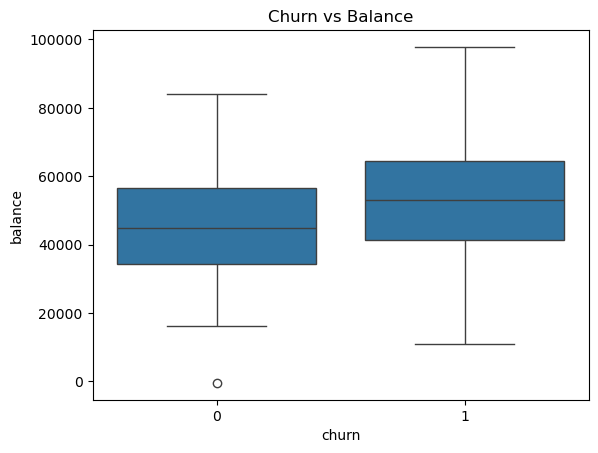

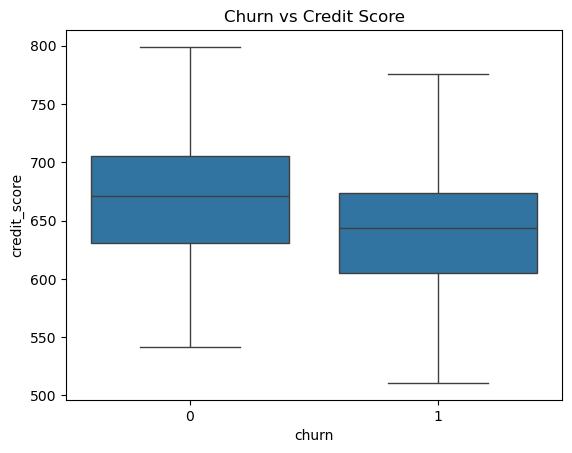

In [15]:
# Keşifsel Analiz

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="churn", y="balance", data=df)
plt.title("Churn vs Balance")
plt.show()

sns.boxplot(x="churn", y="credit_score", data=df)
plt.title("Churn vs Credit Score")
plt.show()

# Churn edenlerin bakiyesi ve kredi skoru farklı mı?
# Grafikler logistic model için sezgisel ipucu verir

In [4]:
# Logistic Regresyon Modeli

import statsmodels.api as sm

X = df[["age", "balance", "credit_score"]]
X = sm.add_constant(X)
y = df["churn"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()

print(result.summary())


Optimization terminated successfully.
         Current function value: 0.623256
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                  300
Model:                          Logit   Df Residuals:                      296
Method:                           MLE   Df Model:                            3
Date:                Sun, 14 Dec 2025   Pseudo R-squ.:                 0.09429
Time:                        15:42:00   Log-Likelihood:                -186.98
converged:                       True   LL-Null:                       -206.44
Covariance Type:            nonrobust   LLR p-value:                 1.796e-08
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            5.5277      1.645      3.360      0.001       2.303       8.752
age              0.0127

**1. Optimizasyon Bilgisi**

* **Current function value: 0.623256**  Logistic regresyonda model, yanlış tahminleri cezalandıran bir olasılık kaybını minimize eder.
Bu değer, her bir gözlem için ortalama ne kadar ‘olasılık hatası’ yapıldığını gösterir. Bu değer tek başına yorumlanmaz. Model karşılaştırmasında anlamlıdır: Daha küçük → daha iyi </br>

**2. Genel Model Bilgileri**

* **Iterations: 5** Model 5 iterasyonda yakınsamış → hızlı ve stabil.

* **Dep. Variable: churn** Bağımlı değişken: churn (0–1) → Logistic regresyon doğru model seçimi.

* **Model: Logit**  Kullanılan model: Binary Logistic Regression

* **Method: MLE** Tahmin yöntemi: Maximum Likelihood Estimation

* **No. Observations: 300** Toplam gözlem sayısı: 300

* **Df Residuals: 296** Serbestlik derecesi: 300−(3 deg˘​is¸​ken +1 intercept)=296

* **Df Model: 3** Üç bağımsız değişken var. age, balance, credit_score

* **converged: True** Optimizasyon başarıyla yakınsamış → model güvenilir

* **Covariance Type: nonrobust** Standart hatalar klasik varsayımlarla hesaplanmış.

**3.. Modelin Genel Anlamlılığı**

* **Log-Likelihood = –186.98** Bu modelin veriyi açıklama gücü.

* **LL-Null = –206.44** Sadece intercept içeren modelin log-likelihood’u.

**Karşılaştırma**

−186.98>−206.44 → Bağımsız değişkenler modeli ciddi şekilde iyileştirmiş.

* **LLR p-value = 1.796e-08** Bu değer şu hipotezi test eder: H0​:β1​=β2​=β3​=0 p ≪ 0.05 → Model genel olarak çok anlamlı

* **Pseudo R-squ.: 0.09429** OLS’teki R² değildir. Model karşılaştırma amaçlıdır. %9.4 → Logistic modeller için makul, özellikle davranışsal verilerde normaldir.

**4. Katsayı Tablosunun Yorumlanması**
Bu tablo log-odds cinsindendir.</br>

* **Intercept (const)**
    - coef = 5.5277, p = 0.001
    - Diğer tüm değişkenler 0 iken log-odds = 5.53
    - Base-rate (temel churn eğilimi) oldukça yüksek
    - $e^{5.5277}≈250$
    - Model, açıklayıcılar olmasa bile churn ihtimalinin yüksek olduğunu varsayıyor.
* **age**
    - coef = 0.0127, p = 0.166
    - Yaş arttıkça churn artıyor gibi görünüyor
    - Ama p > 0.05 → istatistiksel olarak anlamlı değil
    - Yaş, diğer değişkenler varken churn’ü açıklamakta yeterince güçlü değil.
    - Bu durumda; Modelden çıkarılabilir veya Ya da non-linear etki (age²) denenebilir.
* **balance**
    - coef = 3.203e-05, p = 0.000
    - Çok küçük görünmesi ölçekten kaynaklanır
    - İstatistiksel olarak çok anlamlı
    - Odds ratio: $e^{0.000032]≈1.000032$
    - Ama 10.000 birim artış için: $e^{0.32}≈1.38$
    - Bakiye arttıkça churn ihtimali anlamlı biçimde artıyor.

* **credit_score**
    - coef = –0.0113, p = 0.000
    - Negatif ve çok anlamlı
    - Odds ratio: $e^{−0.0113}≈0.9887$
    - Kredi skoru arttıkça churn olasılığı azalıyor
    - 50 puan artış için:
    - $e^{−0.565}≈0.57$
    - churn ihtimali yaklaşık %43 azalır

**5. Güven Aralıkları**
[0.025, 0.975]
- age → aralık 0’ı içeriyor → anlamsız
- balance → 0’ı içermiyor → anlamlı
- credit_score → 0’ı içermiyor → anlamlı
Bu, p-değeri yorumlarını doğrular.

**6. Modelin Genel Yorumu**
- Model genel olarak çok anlamlı
- balance ve credit_score güçlü açıklayıcılar
- MLE yakınsaması başarılı
- age anlamsız → sadeleştirilebilir
- Etkiler odds üzerinden yorumlanmalı

In [5]:
# Odds Ratio Hesaplama

odds_ratios = np.exp(result.params)
odds_ratios


const           251.558065
age               1.012830
balance           1.000032
credit_score      0.988723
dtype: float64

In [19]:
# Tahmin ve Sınıflandırma

df["prob_churn"] = result.predict(X)
df["predicted_churn"] = (df["prob_churn"] >= 0.5).astype(int)


<Axes: >

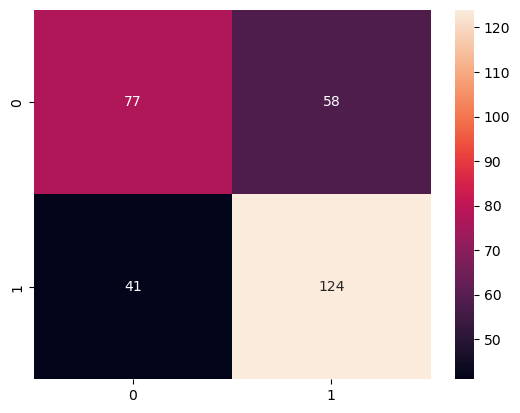

In [24]:
# Confusion Matrix & Accuracy

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
cm = confusion_matrix(df["churn"], df["predicted_churn"])

sns.heatmap(cm, annot=True, fmt='d')


In [25]:
print(classification_report(df["churn"], df["predicted_churn"]))

              precision    recall  f1-score   support

           0       0.65      0.57      0.61       135
           1       0.68      0.75      0.71       165

    accuracy                           0.67       300
   macro avg       0.67      0.66      0.66       300
weighted avg       0.67      0.67      0.67       300




# 1)  Confusion Matrix

Binary sınıflandırmada (pozitif sınıf = 1 diyelim):

|              |                Gerçek 1 |                Gerçek 0 |
| ------------ | ----------------------: | ----------------------: |
| **Tahmin 1** |  **TP** (True Positive) | **FP** (False Positive) |
| **Tahmin 0** | **FN** (False Negative) |  **TN** (True Negative) |

* **TP**: 1 olanı 1 tahmin ettin (doğru “pozitif”)
* **FP**: 0 olanı 1 tahmin ettin (yanlış alarm)
* **FN**: 1 olanı 0 tahmin ettin (kaçırdın)
* **TN**: 0 olanı 0 tahmin ettin (doğru “negatif”)

Bu dört sayıdan precision/recall/F1 türetilir.



# 2) Precision (Kesinlik) nedir?

## Tanım

**Modelin “1” dediği örneklerin ne kadarı gerçekten 1?**

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

## Sezgisel yorum

* “Ben churn olacak dediğimde, ne kadar isabetliyim?”
* Precision düşükse → çok **yanlış alarm** (FP) veriyorsunuz.

## Ne zaman kritik?

* Yanlış alarm **maliyetliyse**:

  * “churn olacak” deyip gereksiz indirim vermek
  * “fraud” deyip masum işlemi bloke etmek
  * “hasta” deyip gereksiz tetkik yapmak

**Özet:** Precision = *pozitif tahminlerimin güvenilirliği*



# 3) Recall (Duyarlılık / Yakalama Oranı) nedir?

## Tanım

**Gerçekten 1 olanların ne kadarını yakalayabildim?**

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

## Sezgisel yorum

* “Gerçek churn eden müşterilerin kaçını yakaladım?”
* Recall düşükse → çok **kaçırma** (FN) var demektir.

## Ne zaman kritik?

* Kaçırmak **daha maliyetliyse**:

  * churn eden müşteriyi kaçırmak (müşteri kaybı)
  * hastalığı kaçırmak (tıbbi risk)
  * dolandırıcılığı kaçırmak (para kaybı)

**Özet:** Recall = *gerçek pozitifleri yakalama gücüm*


# 4) Precision vs Recall arasındaki trade-off

Threshold (eşik) ile oynadığınızda genelde:

* Eşiği **düşürürseniz** (ör. 0.5 → 0.3):

  * Daha çok kişiye “1” dersiniz
  * **Recall artar** (daha çok yakalarsınız)
  * **Precision düşer** (yanlış alarm artar)

* Eşiği **yükseltirseniz** (0.5 → 0.7):

  * Daha az kişiye “1” dersiniz
  * **Precision artar** (daha seçici)
  * **Recall düşer** (daha çok kaçırma)

Bu yüzden “en iyi metrik” diye tek bir cevap yok; problem maliyetine göre seçilir.



# 5) F1-score nedir?

## Tanım

Precision ve recall’u tek sayıda özetleyen **harmonik ortalama**:

$$
F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

## Neden harmonik ortalama?

Aritmetik ortalama gibi “birini çok yüksek yapınca diğerini görmezden gelmez”.
İkisi de iyi değilse F1 yükselmez.

### Örnek

* Precision = 1.00, Recall = 0.10 → F1 ≈ 0.18 (düşük!)
* Precision = 0.70, Recall = 0.70 → F1 = 0.70 (iyi)

**Özet:** F1 = *precision ve recall dengesi*



# 6) “Support” neydi?

Support = o sınıfa ait gerçek gözlem sayısı.
Örneğin churn=1 için support=165 ise gerçek 1 sayısı 165.

Support önemlidir çünkü:

* Az support → metrikler daha oynak (variance yüksek)
* Sınıf dengesizliği olduğunda “weighted average” gibi özetler support’a göre ağırlıklandırılır.




# 7) Makro / Weighted ortalamalar (kısa ama kritik)

* **Macro avg**: Her sınıfı eşit önemser (0 ve 1 eşit ağırlık)
* **Weighted avg**: Sınıf büyüklüğüne göre ağırlık verir (support ile)

Sınıf dengesizliğinde:

* Macro avg düşebilir (azınlık sınıfı kötü yakalanıyorsa)
* Weighted avg yüksek görünebilir (çoğunluk sınıfı baskınsa)



# 8) Tek Cümlelik Notlar

* **Precision:** “1 dediklerimin kaçı gerçekten 1?”
* **Recall:** “Gerçek 1’lerin kaçı yakalandı?”
* **F1:** “Precision–recall dengesi (ikisi birden iyi olmalı)”



Yularıdaki tablo, logistic regresyon modelinin sınıflandırma performansını şu açılardan değerlendirir:
* precision → “tahmin ettiklerim ne kadar doğru?”
* recall → “gerçek pozitifleri ne kadar yakaladım?”
* f1-score → precision & recall dengesi
* support → gerçek gözlem sayısı

**Class 0 (churn = 0, yani terk ETMEYEN)**

| Metric    | Değer |
| --------- | ----- |
| Precision | 0.65  |
| Recall    | 0.57  |
| F1-score  | 0.61  |
| Support   | 135   |

**Precision = 0.65**

Model “churn=0” dediği gözlemlerin %65’i gerçekten churn=0.

Yani:

“Bu müşteri terk etmez” dediğimde %35 hata yapıyorum.


**Recall = 0.57**

Gerçekte churn=0 olan müşterilerin sadece %57’sini yakalayabilmiş.

%43’lük bir kısmı yanlışlıkla churn=1 diye etiketlenmiş.

Bu, modelin 0 sınıfını biraz kaçırdığını gösterir.

**F1-score = 0.61**

Precision ve recall arasında orta düzey bir denge.


**Class 1 (churn = 1, yani terk EDEN)**

| Metric    | Değer |
| --------- | ----- |
| Precision | 0.68  |
| Recall    | 0.75  |
| F1-score  | 0.71  |
| Support   | 165   |

**Precision = 0.68**

Model “churn=1” dediğinde %68 ihtimalle doğru.

%32 yanlış alarm var (false positive).

**Recall = 0.75**

Gerçek churn eden müşterilerin %75’ini yakalayabilmiş.

Bu çok önemli çünkü churn problemlerinde:

Recall(1) genelde en kritik metriktir.


**F1-score = 0.71**

Class 1 için iyi bir denge var.


**Genel Performans Metrikleri**
**Accuracy = 0.67** </br>

Model tüm gözlemlerin %67’sini doğru sınıflandırmış.

**Macro Average = 0.66**</br>
Her sınıfa eşit ağırlık vererek hesaplanan ortalama. </br>
Model, iki sınıfa da benzer seviyede performans gösteriyor.

**Weighted Average = 0.67**
Sınıf büyüklüklerine göre ağırlıklandırılmış ortalama.</br>
Macro ve weighted ortalamanın yakın olması:
- Sınıf dengesinin iyi
- Modelin tek bir sınıfa aşırı kaymadığını gösterir

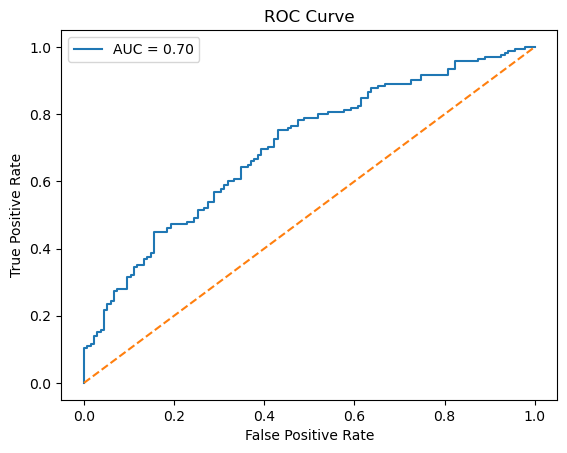

In [28]:
# ROC Eğrisi ve AUC

from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(df["churn"], df["prob_churn"])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
# AUC:
# 0.5 → rastgele
# 0.7–0.8 → kabul edilebilir
# 0.8–0.9 → iyi
# > 0.9 → çok iyi




# ROC–AUC Üzerinden Optimal Eşik (Threshold) Seçimi

Normalde logistic regresyonda varsayılan eşik:

$
\hat{y} =
\begin{cases}
1 & \text{if } p \ge 0.5 \\
0 & \text{if } p < 0.5
\end{cases}
$

Ancak:

* 0.5 **zorunlu değildir**
* Çoğu gerçek problemde **optimal değildir**

ROC eğrisi, **hangi eşiğin daha iyi denge sağladığını** bulmamıza yardım eder.

---

## 1️⃣ ROC Eğrisi Ne Gösterir?

ROC eğrisi:

* **TPR (Recall / Sensitivity)**
* **FPR (1 − Specificity)**

arasındaki ilişkiyi **tüm eşikler için** gösterir.

Her ROC noktası → **farklı bir threshold** demektir.

---

## 2️⃣ Optimal Eşik Nasıl Tanımlanır?

En yaygın ve öğretici yöntem:

### ✅ **Youden’s J İstatistiği**

$
J = \text{TPR} - \text{FPR}
$

Amaç:
$
\max (TPR - FPR)
$

En iyi **ayrım gücüne sahip eşik**



In [29]:
# 3.1. ROC Eğrisi Değerlerini Hesapla

from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

y_true = df["churn"]
y_prob = df["prob_churn"]   # logistic modelden gelen olasılıklar

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

auc_score = roc_auc_score(y_true, y_prob)
auc_score

0.7004264870931538

In [30]:
# 3.2. Youden’s J ile Optimal Threshold

youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]

optimal_threshold


0.5004170523175618

 Bu değer:

* **0.5’ten farklı** olacaktır
* ROC açısından **en dengeli** noktadır

In [31]:
# Optimal Threshold ile Yeni Tahminler

df["pred_optimal"] = (df["prob_churn"] >= optimal_threshold).astype(int)

# Yeni Classification Report


from sklearn.metrics import classification_report

print(classification_report(df["churn"], df["pred_optimal"]))



              precision    recall  f1-score   support

           0       0.65      0.57      0.61       135
           1       0.68      0.75      0.71       165

    accuracy                           0.67       300
   macro avg       0.67      0.66      0.66       300
weighted avg       0.67      0.67      0.67       300



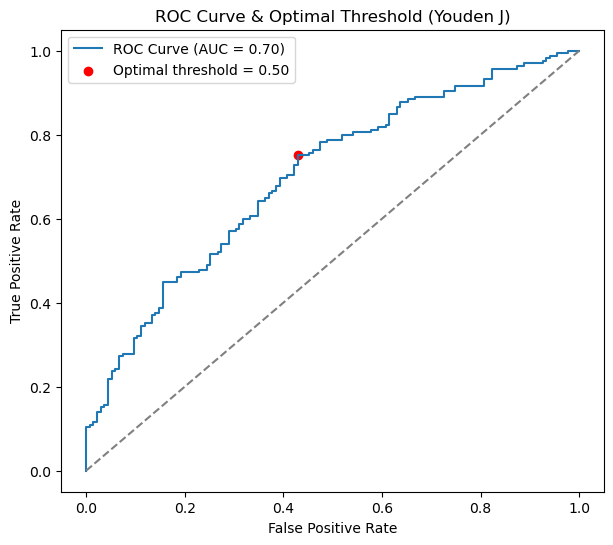

In [32]:

# ROC Eğrisi Üzerinde Optimal Noktanın Gösterimi

import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.scatter(
    fpr[optimal_idx],
    tpr[optimal_idx],
    color="red",
    label=f"Optimal threshold = {optimal_threshold:.2f}"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve & Optimal Threshold (Youden J)")
plt.legend()
plt.show()



# Sonuçların Yorumlanması

- “0.5 eşik değeri matematiksel bir zorunluluk değildir.
- ROC eğrisi, problemimize en uygun karar eşiğini seçmemizi sağlar.”

# Churn Problemleri İçin Özel Yorum

* Eğer **churn kaçırmak pahalıysa** → threshold ↓
* Eğer **yanlış alarm pahalıysa** → threshold ↑

ROC tabanlı eşik:

* **istatistiksel olarak dengeli**
* ama **iş maliyetlerini doğrudan içermez**



# Not

ROC–AUC:

* Sınıf dengesizliğinden **bağımsızdır**
* Ama **optimal threshold seçimi probleme özgüdür**

Bu yüzden:

* ROC → genel ayrım gücü
* Threshold → operasyonel karar


# Özet

**ROC–AUC üzerinden optimal eşik, TPR ile FPR arasındaki farkı maksimize eden ve modelin sınıfları en iyi ayırdığı karar noktasıdır.**

# Support Vector Regression (SVR)

Support Vector Regression, Support Vector Machines (SVM) ailesinin sürekli (sayısal) bağımlı değişkenler için kullanılan versiyonudur.</br>

**Amaç**, Veriyi mümkün olduğunca düz (flat) bir fonksiyonla açıklarken, ε (epsilon) toleransı içinde kalan hataları önemsiz saymak.</br>

**Yani**, SVR şunu söyler: “Modelim çok karmaşık olmasın (düz olsun), ama küçük hatalar için de kendimi yıpratmayayım.”</br>

    - 
**“Veriyi mümkün olduğunca düz (flat) bir fonksiyonla açıklamak” ne demek?**
* Düz (flat) fonksiyon:
    - Eğimi çok yüksek olmayan
    - Gereksiz kıvrımları olmayan
    - Basit bir model
**Yani**, Model her noktaya tek tek yapışmaya çalışmasın. Genel eğilimi yakalaması yeterli.</br>


**ε (epsilon) toleransı içinde kalan hatalar” ne demek?**
* SVR, regresyon doğrusunun etrafına bir hata bandı (tüp) çizer. Aşağıdaki örneğe bakalım.


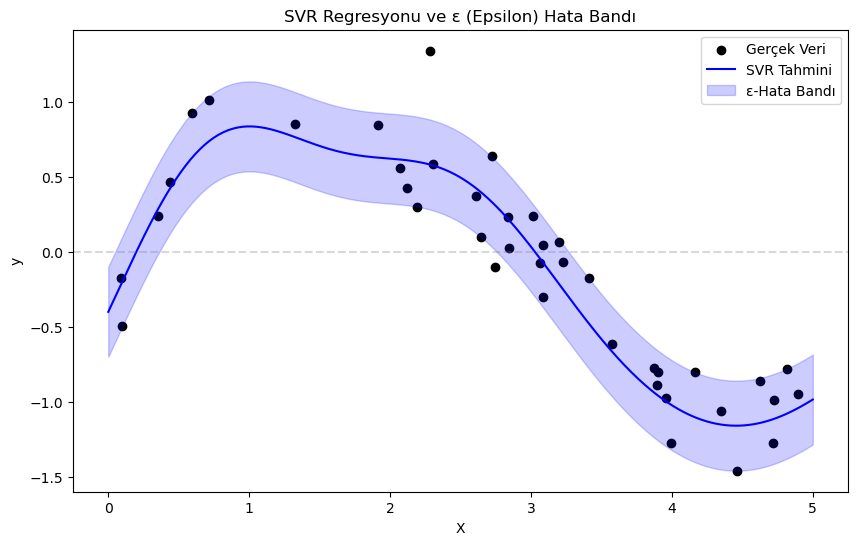

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# Örnek Veri Üretimi
np.random.seed(0)
X = np.sort(5 * np.random.rand(40, 1), axis=0)
y = np.sin(X).ravel() + 0.3 * np.random.randn(40)

# SVR Modeli (RBF Kernel)
epsilon = 0.3
svr = SVR(kernel='rbf', C=100, epsilon=epsilon)
svr.fit(X, y)

# Tahmin ve Epsilon Bandı
X_test = np.linspace(0, 5, 300).reshape(-1, 1)
y_pred = svr.predict(X_test)

upper_band = y_pred + epsilon
lower_band = y_pred - epsilon

# Grafik: SVR + ε-Tüp
plt.figure(figsize=(10,6))

# Gerçek veri
plt.scatter(X, y, color='black', label='Gerçek Veri')

# SVR tahmini
plt.plot(X_test, y_pred, color='blue', label='SVR Tahmini')

# Epsilon bandı
plt.fill_between(
    X_test.ravel(),
    lower_band,
    upper_band,
    color='blue',
    alpha=0.2,
    label='ε-Hata Bandı'
)

plt.axhline(0, color='gray', linestyle='--', alpha=0.3)

plt.xlabel("X")
plt.ylabel("y")
plt.title("SVR Regresyonu ve ε (Epsilon) Hata Bandı")
plt.legend()
plt.show()

# Mavi çizgi: SVR’nin bulduğu regresyon fonksiyonu
# AMor alan: ε tolerans bandı
# Bu bandın içindeki noktalar hata sayılmaz
# Bandın dışına çıkan noktalar cezalandırılır
# Sadece bu noktalar support vector olur

**Bu bant içindeki hatalar önemsiz sayılır” ne demek?**
Tahminim gerçek değerden biraz sapabilir, ama bu sapma ε kadar küçükse bunu hata olarak saymıyorum.</br>

* Klasik regresyon:
  - 0.01 hata → ceza
  - 0.5 hata → ceza
  - 2 hata → ceza
* SVR
  - |hata| ≤ ε → önemsiz
  - |hata| > ε → cezalandırılır

Diyelim ki:
- Gerçek değer: 100
- ε = 5

| Tahmin | Hata | SVR’nin Tepkisi |
| ------ | ---- | --------------- |
| 102    | 2    | Önemli değil    |
| 96     | 4    | Önemli değil    |
| 105    | 5    | Önemli değil    |
| 108    | 8    | Ceza var        |

**Neden Böyle Bir Yaklaşım Var?**
- Gerçek veriler gürültülüdür
- Ölçüm hataları vardır
- Küçük farklar çoğu zaman anlamsızdır

SVR’nin felsefesi:</br>
Her küçük farkı açıklamaya çalışma, asıl önemli olan büyük sapmaları kontrol altına almak.

**Parametreler**
* **kernel :**  Verinin hangi uzayda modelleneceğini belirler.

| Kernel    | Anlamı          | Ne Zaman Kullanılır   |
| --------- | --------------- | --------------------- |
| `linear`  | Doğrusal ilişki | Basit veri            |
| `poly`    | Polinom ilişki  | Eğrisel yapı          |
| `rbf`     | Gauss tabanlı   | Karmaşık / lokal yapı |
| `sigmoid` | NN benzeri      | Nadiren               |

SVR’de varsayılan ve en güçlü kernel: rbf'dir.

* **C (Regularization) :** Hatalara ne kadar tolerans gösterileceğini belirler.
  - Küçük C → yumuşak model → underfitting
  - Büyük C → sert model → overfitting

* **epsilon (ε) :** Hata bandının genişliği.
  - Küçük ε → hassas model
  - Büyük ε → küçük hatalar yok sayılır

* **gamma (RBF ve poly için) :** Tek bir noktanın etki alanını belirler.
  - Küçük γ → geniş etki alanı (düz eğri)
  - Büyük γ → lokal etki (kıvrımlı eğri)


**Örnek Uygulama**

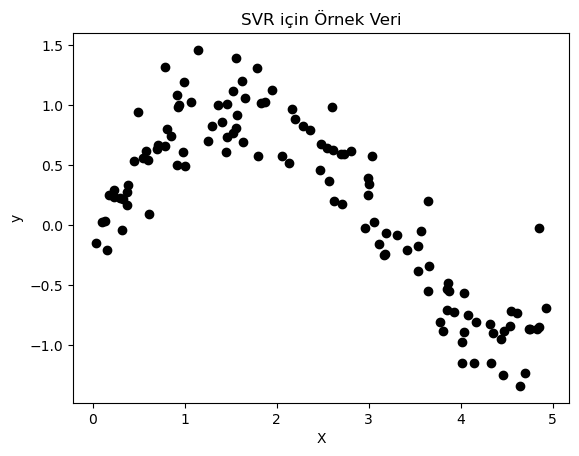

In [12]:
# Veri Üretimi (Doğrusal Olmayan Yapı)
# Veri doğrusal olamdığı için Lineer Regresyon Uygulanamaz
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.sort(5 * np.random.rand(120, 1), axis=0)
y = np.sin(X).ravel() + 0.25 * np.random.randn(120)

plt.scatter(X, y, color='black')
plt.title("SVR için Örnek Veri")
plt.xlabel("X")
plt.ylabel("y")
plt.show()


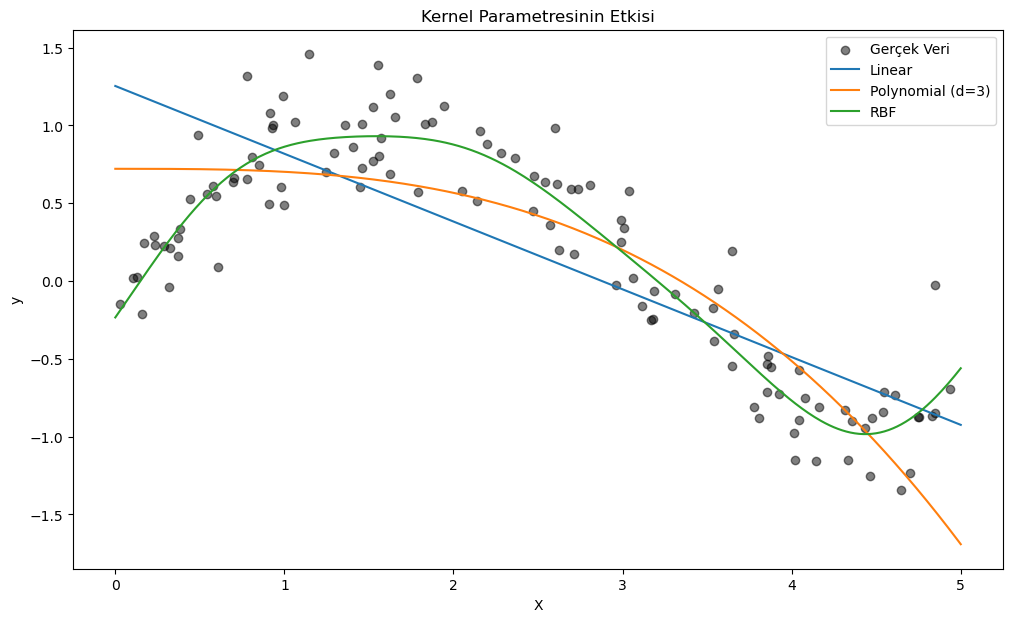

In [15]:
# Kernel Parametresinin Etkisi
from sklearn.svm import SVR

kernels = {
    "Linear": SVR(kernel='linear', C=100, epsilon=0.1),
    "Polynomial (d=3)": SVR(kernel='poly', degree=3, C=100, epsilon=0.1),
    "RBF": SVR(kernel='rbf', C=100, epsilon=0.1)
}

X_test = np.linspace(0, 5, 400).reshape(-1, 1)

plt.figure(figsize=(12,7))
plt.scatter(X, y, color='black', alpha=0.5, label="Gerçek Veri")

for name, model in kernels.items():
    model.fit(X, y)
    y_pred = model.predict(X_test)
    plt.plot(X_test, y_pred, label=name)

plt.title("Kernel Parametresinin Etkisi")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# Yorum
# Linear: Yapıyı yakalayamıyor → underfitting
# Polynomial: Kısmen yakalıyor
# RBF: En iyi uyum → varsayılan tercih

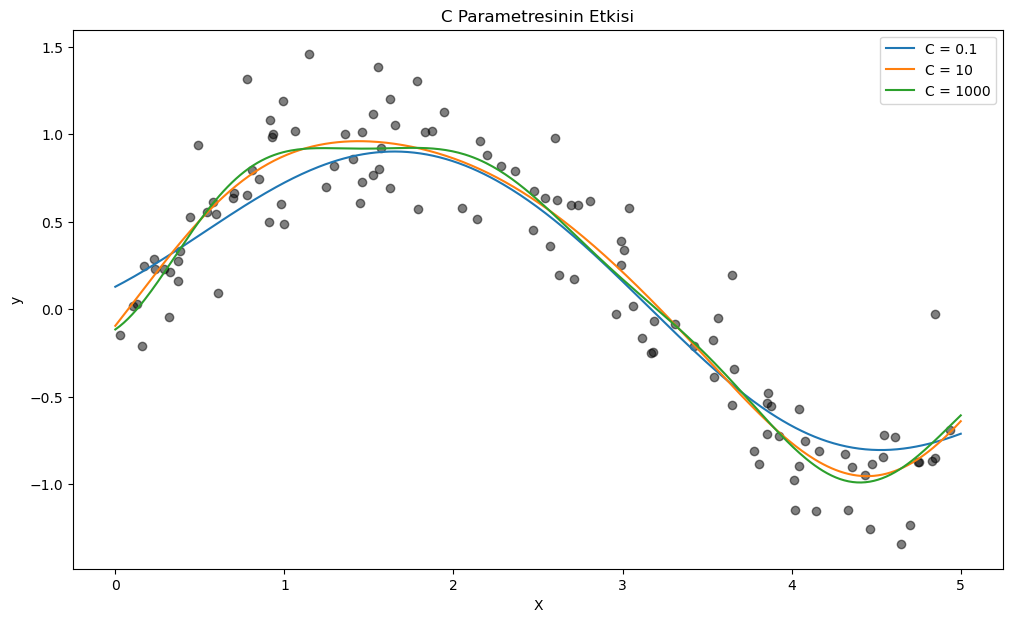

In [17]:
# C Parametresinin Etkisi
C_values = [0.1, 10, 1000]

plt.figure(figsize=(12,7))
plt.scatter(X, y, color='black', alpha=0.5)

for C in C_values:
    model = SVR(kernel='rbf', C=C, epsilon=0.1)
    model.fit(X, y)
    y_pred = model.predict(X_test)
    plt.plot(X_test, y_pred, label=f"C = {C}")

plt.title("C Parametresinin Etkisi")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# C arttıkça model veriye daha çok yapışır

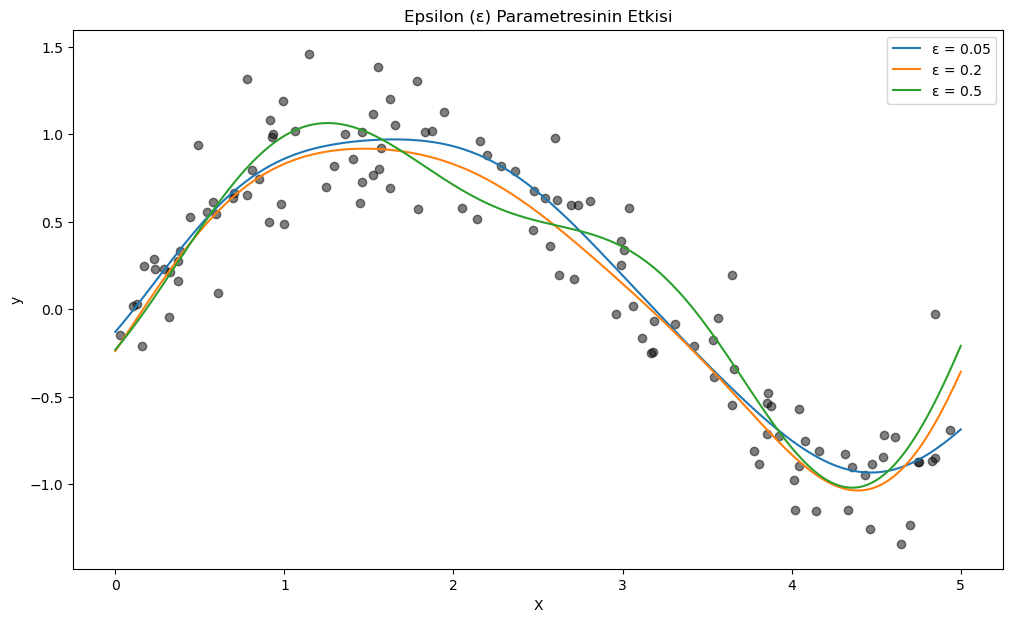

In [19]:
# Epsilon (ε) Parametresinin Etkisi

eps_values = [0.05, 0.2, 0.5]

plt.figure(figsize=(12,7))
plt.scatter(X, y, color='black', alpha=0.5)

for eps in eps_values:
    model = SVR(kernel='rbf', C=100, epsilon=eps)
    model.fit(X, y)
    y_pred = model.predict(X_test)
    plt.plot(X_test, y_pred, label=f"ε = {eps}")

plt.title("Epsilon (ε) Parametresinin Etkisi")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# ε büyüdükçe model daha “umursamaz” olur

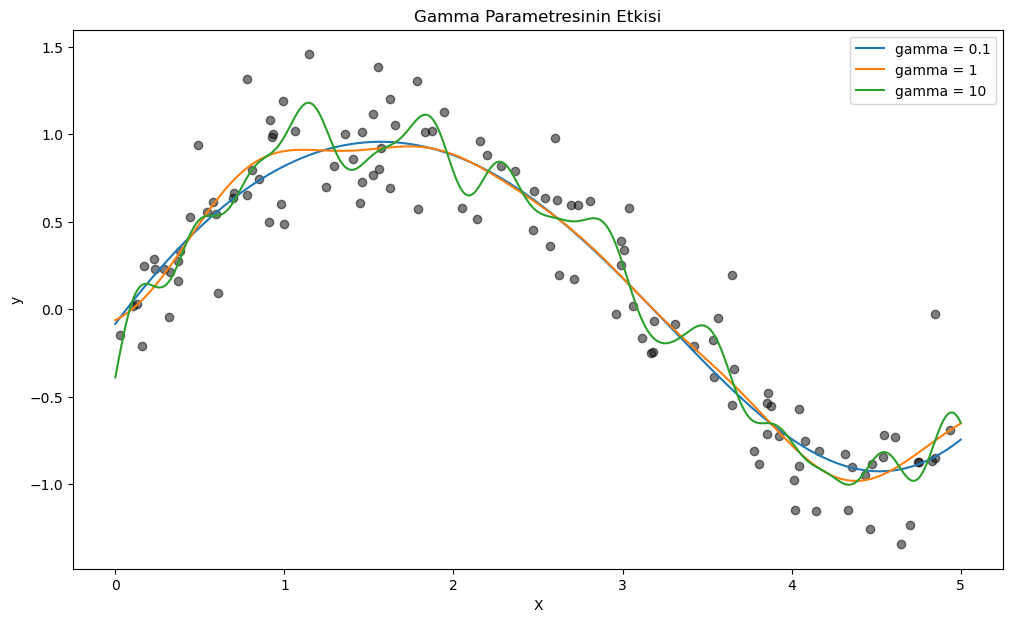

In [22]:
# Gamma Parametresinin Etkisi (RBF)

gamma_values = [0.1, 1, 10]

plt.figure(figsize=(12,7))
plt.scatter(X, y, color='black', alpha=0.5)

for gamma in gamma_values:
    model = SVR(kernel='rbf', C=100, epsilon=0.1, gamma=gamma)
    model.fit(X, y)
    y_pred = model.predict(X_test)
    plt.plot(X_test, y_pred, label=f"gamma = {gamma}")

plt.title("Gamma Parametresinin Etkisi")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# Gamma büyüdükçe model lokal davranır.
# Lokal Davranma : Model, her veri noktasını sadece kendi yakın çevresiyle ilişkilendirir.

# Büyük gamma -> Her noktanın etki alanı daralır, Noktalar yalnızca çok yakın komşularını etkiler. Model; Daha kıvrımlı, Daha detaycı, 
# Gürültüye duyarlı olur. Yani sonuç olarak;Model çok lokal çalışır → overfitting riski

# Küçük gamma -> Her nokta geniş bir alanı etkiler, Uzak noktalar bile birbirini etkiler. Model; Daha düz, Daha genelleyici, Daha Stabil.
# Yani sonuç olarak; Model global davranır → underfitting riski

In [26]:
# Regresyon Metrikleri
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

svr_linear = SVR(kernel='linear', C=100, epsilon=0.1)
svr_rbf = SVR(kernel='rbf', C=100, epsilon=0.1, gamma=1)
svr_poly = SVR(kernel='poly', degree=3, C=100, epsilon=0.1)


models = {
    "Linear SVR": svr_linear,
    "RBF SVR": svr_rbf,
    "Polynomial SVR": svr_poly
}

print("MODEL PERFORMANSLARI\n")


for name, model in models.items():
    model.fit(X, y)
    y_pred_train = model.predict(X)
    
    mse = mean_squared_error(y, y_pred_train)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred_train)
    r2 = r2_score(y, y_pred_train)
    print(f'{model} için sonuçlar : mse = {mse}, rmse = {rmse}, mae = {mae}, r2 = {r2}' )

MODEL PERFORMANSLARI

SVR(C=100, kernel='linear') için sonuçlar : mse = 0.25574412629180926, rmse = 0.5057115050024167, mae = 0.39637115998565553, r2 = 0.5139762292482297
SVR(C=100, gamma=1) için sonuçlar : mse = 0.0535892496722891, rmse = 0.23149351971985976, mae = 0.18205302612387403, r2 = 0.8981573904545304
SVR(C=100, kernel='poly') için sonuçlar : mse = 0.15784603176846615, rmse = 0.39729841651895137, mae = 0.3155207202758471, r2 = 0.7000246900263976


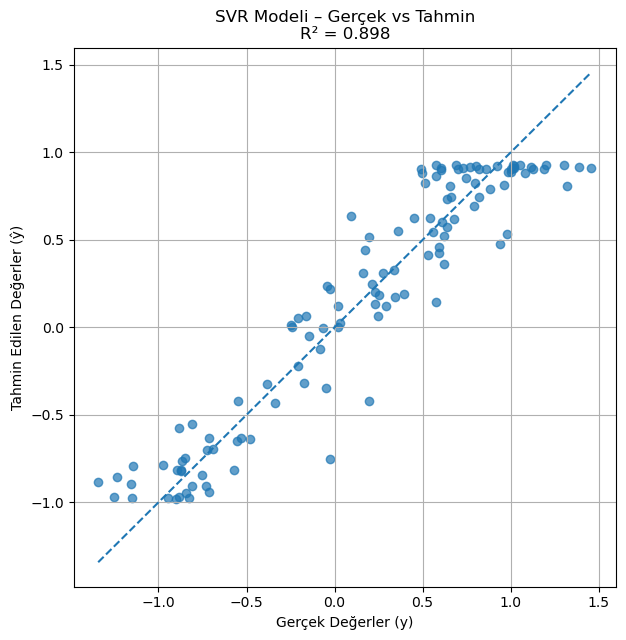

In [27]:
plt.figure(figsize=(7,7))

plt.scatter(y, models['RBF SVR'].predict(X), alpha=0.7)
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    linestyle='--'
)

plt.xlabel("Gerçek Değerler (y)")
plt.ylabel("Tahmin Edilen Değerler (ŷ)")
plt.title(f"SVR Modeli – Gerçek vs Tahmin\nR² = {r2_score(y, models['RBF SVR'].predict(X)):.3f}")

plt.grid(True)
plt.show()


# Random Forest Classifier

Random Forest, birden fazla Decision Tree (Karar Ağacı) modelinin bir araya gelerek oylama (ensemble) yoluyla karar verdiği bir sınıflandırma algoritmasıdır.</br>

**Temel fikir :** Tek bir ağaca güvenme, farklı açılardan bakan birçok ağacın ortak kararını al. </br>

**Neden “Random”?**
Random Forest’ta iki tür rastgelelik vardır:</br>
1. Bootstrap Sampling : Her ağaç, verinin rastgele seçilmiş (tekrarlı) bir alt kümesiyle eğitilir.
2. Feature Randomness : Her düğümde tüm değişkenler değil, rastgele seçilmiş bir alt küme kullanılır

Böylelikle:</br>
- Ağaçlar birbirine benzemez
- Overfitting azalır
- Genelleme gücü artar

**Random Forest ile Tek Karar Ağacı Karşılaştırması**
| Özellik           | Decision Tree | Random Forest |
| ----------------- | ------------- | ------------- |
| Overfitting       | Yüksek        | Düşük         |
| Stabilite         | Düşük         | Yüksek        |
| Yorumlanabilirlik | Yüksek        | Orta          |
| Performans        | Orta          | Yüksek        |


**RandomForestClassifier’ın Temel Parametreleri**
- **n_estimators(Ağaç Sayısı) :** Büyük → daha stabil, ama daha yavaş
- **max_depth (Ağaçların maksimum derinliği) :** Küçük → underfitting, Büyük → overfitting riski
- **max_features (Her bölmede kullanılan değişken sayısı) :** Varsayılan: sqrt(p) p=Veri setindeki bağımsız değişkenlerin sayısı
- **min_samples_split (Bir düğümün bölünmesi için gereken minimum örnek) :**


**Örnek Uygulama**

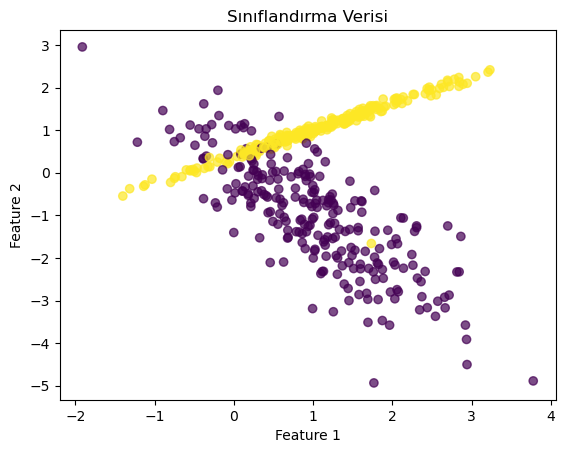

In [29]:
# Örnek Veri Oluşturma

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=500, # Toplam gözlem (örnek) sayısı
    n_features=2, # Toplam özellik (feature) sayısı
    n_informative=2, # Sınıflandırmada gerçekten işe yarayan özellik sayısı
    n_redundant=0, # Bilgi taşımayan (tekrarlı / türetilmiş) özellik sayısı
    n_clusters_per_class=1, # Her sınıfın kaç alt kümeden (cluster) oluştuğu
    random_state=42
)

plt.scatter(X[:,0], X[:,1], c=y, alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Sınıflandırma Verisi")
plt.show()


In [30]:
# Train–Test Ayrımı

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [31]:
# RandomForestClassifier Modeli
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)


In [32]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.96

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.94      0.96        51
           1       0.94      0.98      0.96        49

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



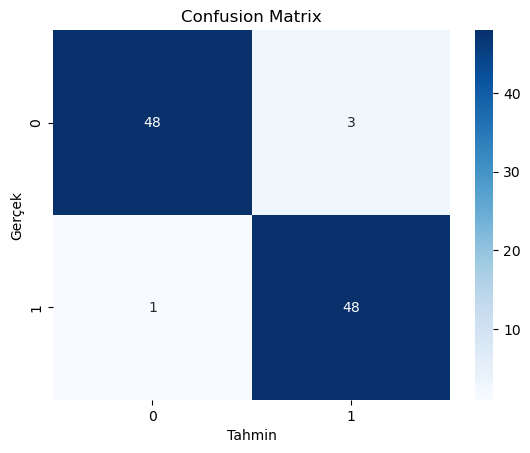

In [33]:
# Confusion Matrix

import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix")
plt.show()


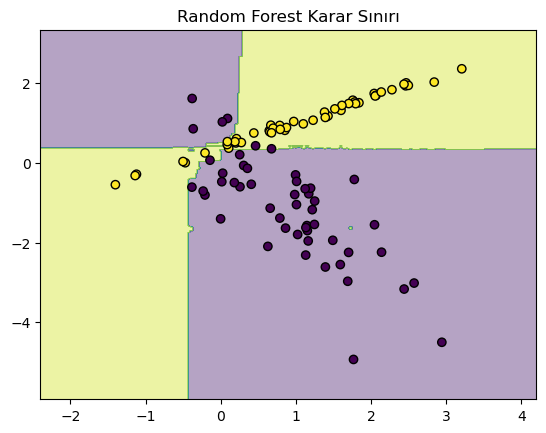

In [34]:
# Karar Sınırlarının Görselleştirilmesi

from matplotlib.colors import ListedColormap

def plot_decision_boundary(model, X, y):
    h = 0.02
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')
    plt.title("Random Forest Karar Sınırı")
    plt.show()

plot_decision_boundary(rf, X_test, y_test)


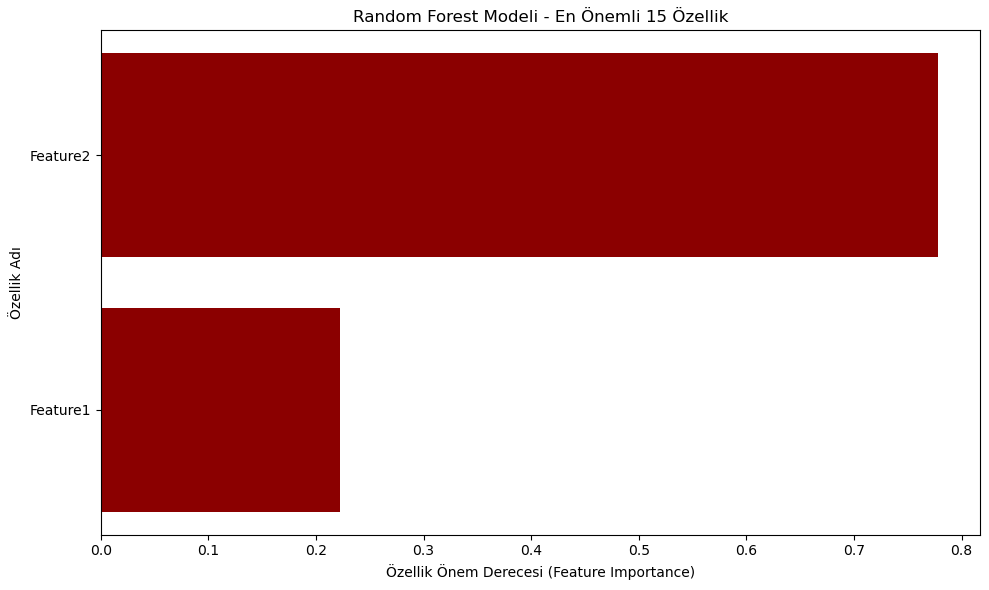

In [39]:
# Feature Importance

import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
feature_names = ['Feature1', 'Feature2']

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# En önemli 10 özelliği seçme
top_n = 15
top_features = feature_importance_df.head(top_n)

# --- 4. Grafik Oluşturma ---
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='darkred')
plt.xlabel('Özellik Önem Derecesi (Feature Importance)')
plt.ylabel('Özellik Adı')
plt.title(f'Random Forest Modeli - En Önemli {top_n} Özellik')
plt.gca().invert_yaxis() # En önemli özellik en üste gelsin
plt.tight_layout()

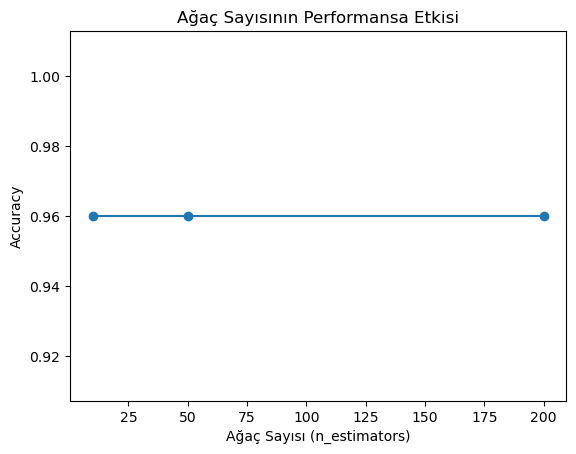

In [40]:
# Parametrelerin Etkisi – Ağaç Sayısı

trees = [10, 50, 200]
accuracies = []

for n in trees:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    accuracies.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(trees, accuracies, marker='o')
plt.xlabel("Ağaç Sayısı (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Ağaç Sayısının Performansa Etkisi")
plt.show()


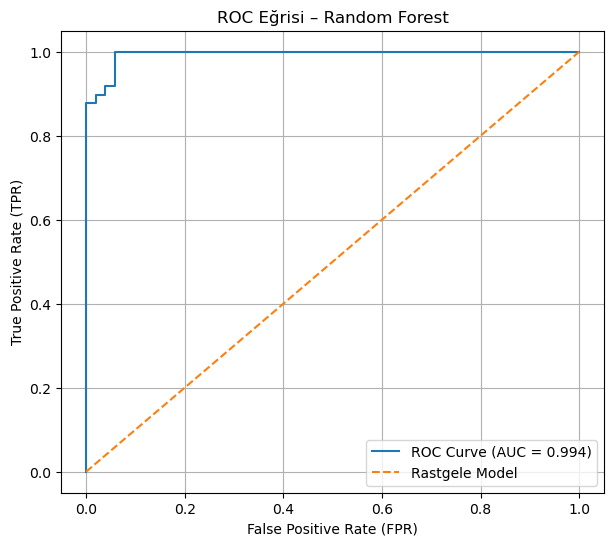

In [42]:
# ROC-AUC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0,1], [0,1], linestyle='--', label="Rastgele Model")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Eğrisi – Random Forest")
plt.legend()
plt.grid(True)
plt.show()

# Eğri sol–üst köşeye ne kadar yakınsa → model o kadar iyi
# Diyagonal çizgi → rastgele tahmin
# AUC → modelin ayırt edicilik gücü

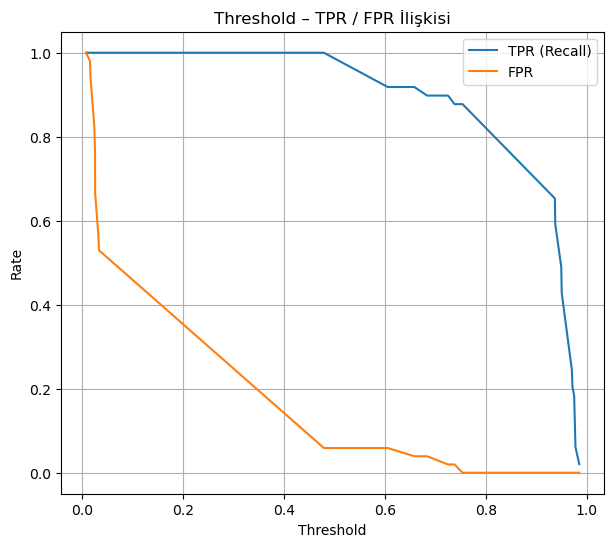

In [43]:
# Threshold – TPR – FPR İlişkisi

plt.figure(figsize=(7,6))
plt.plot(thresholds, tpr, label="TPR (Recall)")
plt.plot(thresholds, fpr, label="FPR")

plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("Threshold – TPR / FPR İlişkisi")
plt.legend()
plt.grid(True)
plt.show()


In [44]:
# Optimal Eşik (Youden’s J İndeksi)

import numpy as np

J = tpr - fpr
best_idx = np.argmax(J)
best_threshold = thresholds[best_idx]

print("Optimal Threshold:", best_threshold)


Optimal Threshold: 0.478731198211303


In [45]:
# Optimal Eşik ile Yeni Tahminler
y_pred_opt = (y_prob >= best_threshold).astype(int)


In [46]:
# Yeni Confusion Matrix

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_opt))
print("\nClassification Report (Optimal Threshold):\n")
print(classification_report(y_test, y_pred_opt))


[[48  3]
 [ 0 49]]

Classification Report (Optimal Threshold):

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        51
           1       0.94      1.00      0.97        49

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



# imbalanced data durumunda

*class_weight="balanced", azınlık sınıfın hatasını daha pahalı hale getirerek modelin onu ciddiye almasını sağlar.*

| Senaryo              | Çözüm                     |
| -------------------- | ------------------------- |
| Orta dengesizlik     | `class_weight="balanced"` |
| Aşırı dengesizlik    | + SMOTE / undersampling   |
| Recall çok önemli    | `balanced` + threshold ↓  |
| Precision çok önemli | threshold ↑               |
| Kritik maliyet       | Özel `class_weight`       |


